In [1]:
import tensorflow as tf

In [3]:
x1 = tf.constant(5)
x2 = tf.constant(6)
x3 = tf.add(x1, x2)
x3.numpy()

np.int32(11)

In [5]:
v1 = tf.constant([1,2,3,4])
v2 = tf.constant([2,1,5,3])
v3 = v1 + v2
v3.numpy()

array([3, 3, 8, 7], dtype=int32)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('/content/FuelConsumptionCo2.csv')


In [8]:
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [9]:
x_d =data.loc[:,'ENGINESIZE'].values
y_d = data.loc[:,'CO2EMISSIONS'].values


In [15]:
x = tf.constant(x_d, dtype=tf.float32)
y = tf.constant(y_d, dtype=tf.float32)


In [16]:
w = tf.Variable(2.0, dtype=tf.float32)
b = tf.Variable(7.2, dtype=tf.float32)


In [17]:
def H(x):
  y_p =  w * x + b
  return y_p

In [18]:
def cost_function(y_actual, y_pred):
  mse = tf.reduce_mean(tf.square(y_actual - y_pred))
  return mse

In [19]:
lr = 0.01
epochs = 1000
loss_values = []
for epoch in range(epochs):
  with tf.GradientTape() as t:
    y_pred = H(x)
    loss = cost_function(y, y_pred)
    loss_values.append(loss)
    gradient = t.gradient(loss, [w, b])
    w.assign_sub(lr * gradient[0])
    b.assign_sub(lr * gradient[1])


In [20]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=951.5820922851562>

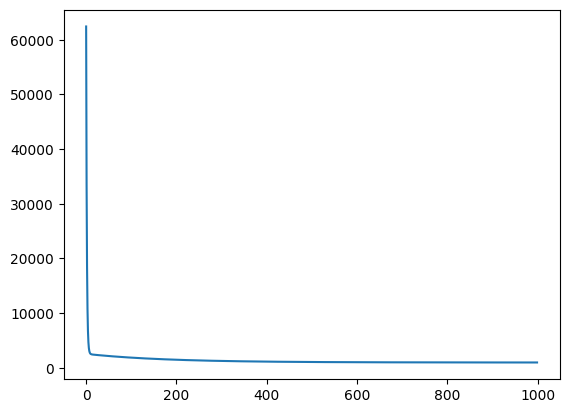

In [21]:
plt.plot(loss_values)
plt.show()

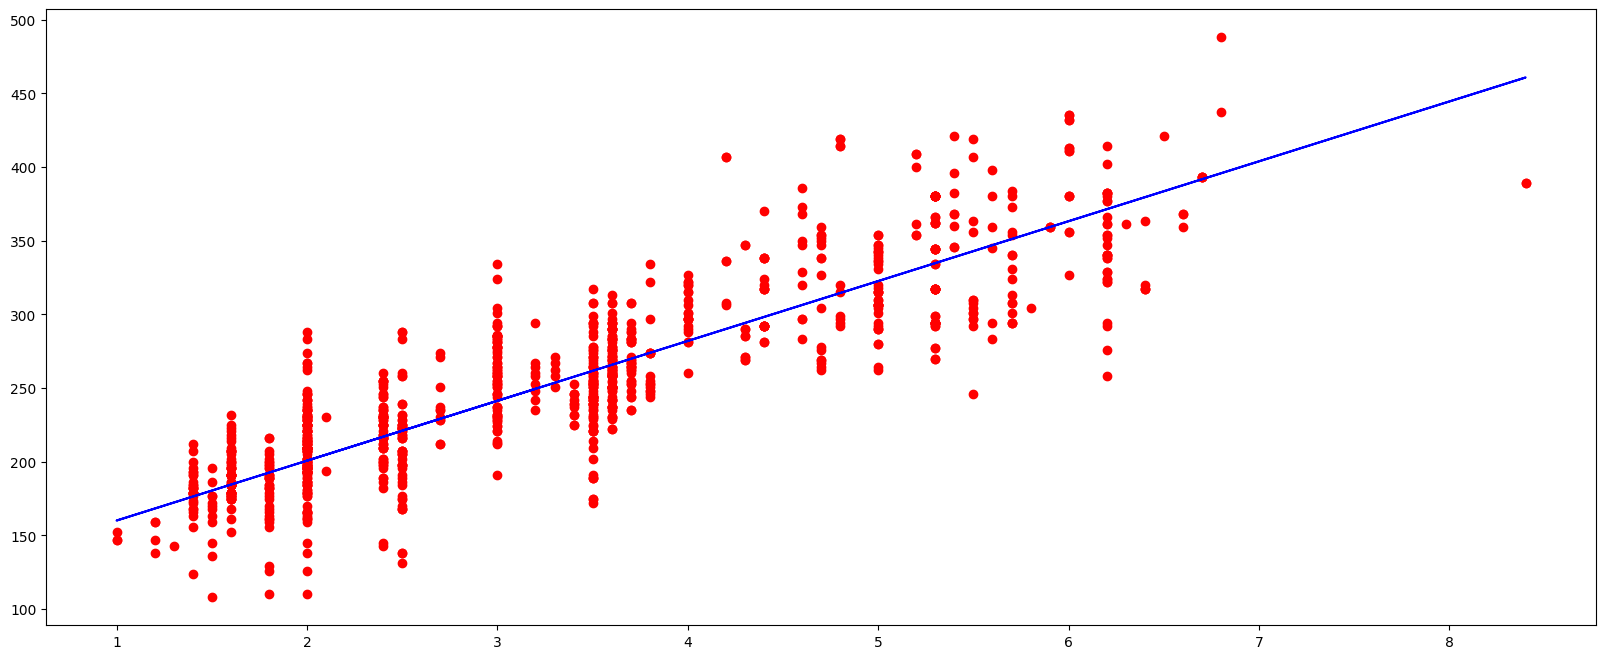

In [22]:
plt.figure(figsize=(20,8))
plt.scatter(x.numpy(), y.numpy(), color='red')
plt.plot(x.numpy(), H(x).numpy(), color='blue')
plt.show()